In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
    transforms.RandomHorizontalFlip()])
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)
trainloader=DataLoader(trainset,batch_size=64,shuffle=True,num_workers=2)
testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
testloader=DataLoader(testset,batch_size=64,shuffle=False,num_workers=2)

class CIFAR10Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,16,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(2,2)
        self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(2,2)
        self.fc1=nn.Linear(64*4*4,512)
        self.fc2=nn.Linear(512,10)
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=x.view(-1,64*8*8)
        x=F.relu(self.fc1(x))
        logits=self.fc2(x)
        return logits
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=CIFAR10Net().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.AdamW(model.parameters(),lr=0.001)
epochs=10
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for i,(images,labels) in enumerate(trainloader):
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()                     
        running_loss+=loss.item()
print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

100.0%
c:\Users\User\.conda\envs\hackathon_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch [5/5], Loss: 0.3872


   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   
5       80175.75416             4.988408                   6.104512   
6       64698.46343             6.025336                   8.147760   
7       78394.33928             6.989780                   6.620478   
8       59927.66081             5.362126                   6.393121   
9       81885.92718             4.423672                   8.167688   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09      23086.80050  1.059034e+06   
1                          3.09      40173.07217  1.505891e+06   
2                   

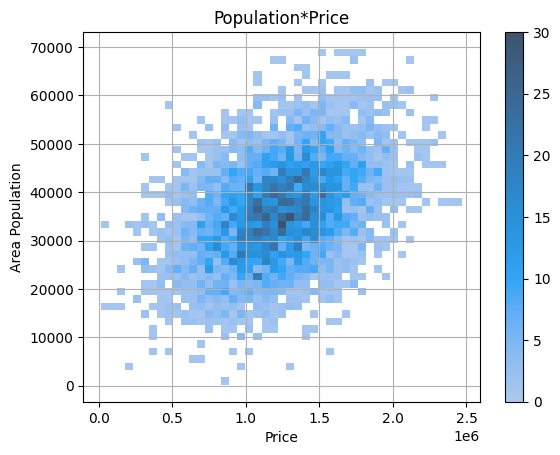

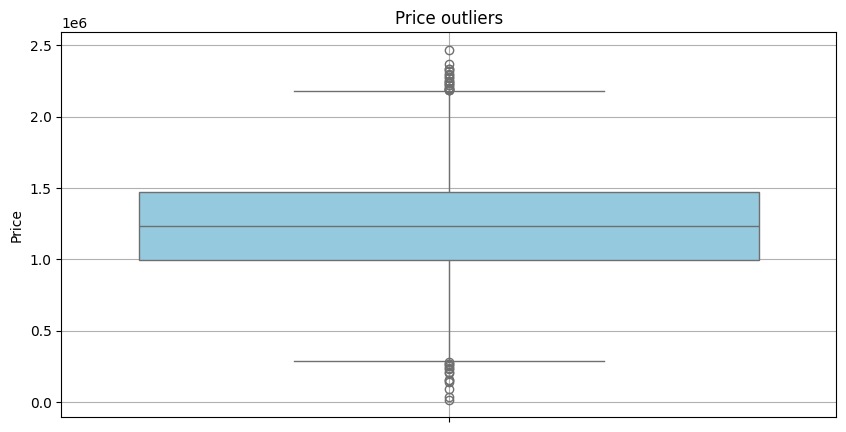

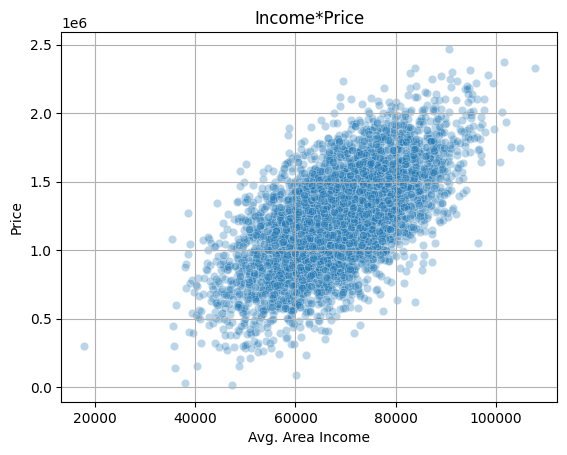

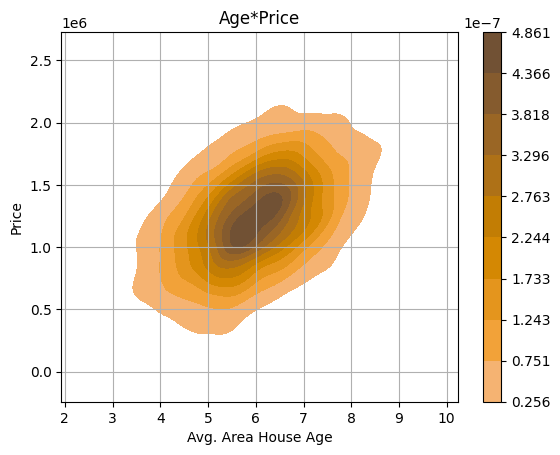

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
df = pd.read_csv("housing.csv")

Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR= Q3 - Q1
lower_bound= Q1 - 1.5*IQR
df_clean = df[df['Price'] >= lower_bound]

print(df.head(10))   
df.info(10) 
print(df.describe())
df.isna().sum().sum()

sns.histplot(data=df, kde=True, x='Price', y='Area Population',cbar=True)
plt.title('Population*Price')  
plt.grid(visible=True)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df,y='Price', color='skyblue',)
plt.grid(visible=True)
plt.title('Price outliers')  
plt.show()
plt.tight_layout()

sns.scatterplot(data=df, x='Avg. Area Income', y='Price', alpha=0.3)
plt.grid(visible=True)
plt.title('Income*Price')
plt.show()

sns.kdeplot(data=df,x='Avg. Area House Age',y='Price', fill=True, color="orange",cbar=True)
plt.title('Age*Price')
plt.grid(visible=True)
plt.show()

In [2]:
import cv2
from ultralytics import YOLO
model = YOLO("yolo26n.pt") 
cap = cv2.VideoCapture(0) 
while cap.isOpened():
    success, frame = cap.read() 
    if success:
        results = model.predict(frame, conf=0.25, iou=0.45, stream=True)
        
        for r in results:
            annotated_frame = r.plot()
            cv2.imshow("YOLOv11 Real-Time Detection", annotated_frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        break
cap.release()
cv2.destroyAllWindows()


0: 480x640 2 persons, 3 bottles, 1 hot dog, 1 cell phone, 146.5ms
Speed: 18.0ms preprocess, 146.5ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 bottles, 1 hot dog, 79.3ms
Speed: 2.0ms preprocess, 79.3ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 bottles, 1 hot dog, 61.0ms
Speed: 1.3ms preprocess, 61.0ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 bottles, 1 hot dog, 60.8ms
Speed: 1.5ms preprocess, 60.8ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 bottles, 1 hot dog, 56.3ms
Speed: 1.1ms preprocess, 56.3ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 3 bottles, 1 hot dog, 60.1ms
Speed: 1.6ms preprocess, 60.1ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 bottles, 1 hot dog, 57.8ms
Speed: 1.1ms preprocess, 57.8ms inference, 

In [ ]:
%pip install transformers


In [1]:
pip install openai


  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 5.2 MB/s  0:00:00
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------- ------------- 1.3/2.0 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 8.6 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
Using 

In [3]:
from openai import AzureOpenAI
client = AzureOpenAI(
    azure_endpoint = "https://foundry-openclaw-prod-resource.openai.azure.com/", 
    api_key = "9zYmDYTzNhRQ1gMVFza1WGRuzhcxpLvNTHIl2Jo6ruCkwHKruIVdJQQJ99CAACfhMk5XJ3w3AAAAACOGQsa8",  
    api_version = "2024-12-01-preview"
)
response = client.chat.completions.create(
    model = "gpt-oss-120b",
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "How do I integrate Azure model to code without leaking my sensitive data - Azure API key, endpoint and version?"}
    ]
)
print(response.choices[0].message.content)

Below is a **step‑by‑step playbook** you can follow to call an Azure model (e.g., Azure OpenAI, Azure Cognitive Services, Azure Machine‑Learning endpoint, etc.) from your code **without ever exposing the API key, endpoint URL, or version string** in source control, logs, or the runtime environment where it could be harvested.

---

## 1. Treat All Secrets as **Secret, Not Code**

| What | Why it matters |
|------|-----------------|
| **API key** – the primary credential that grants access to the service. | If leaked, anyone can call the service and accrue cost on your subscription. |
| **Endpoint URL** – often public, but can reveal the region or tenant. | Hiding it reduces “information leakage” and makes automated attacks harder. |
| **API version** – usually not secret, but you may want to keep it out of code for flexibility. | Keeps your code agnostic to future version upgrades. |

> **Bottom line:** Never hard‑code any of these values in source files that are committed to a reposit

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=50000, stratify=y, random_state=1488)
X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=1488)

full_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', SGDClassifier(random_state=1488))
])
full_pipeline.fit(X_train,y_train)

y_scores=cross_val_predict(full_pipeline,X_train,y_train,cv=5,method="decision_function")
classes=np.unique(y_train)
y_train_pred=classes[np.argmax(y_scores,axis=1)]
test_scores = full_pipeline.decision_function(X_test)

p = precision_score(y_train,y_train_pred,average='macro')
r = recall_score(y_train,y_train_pred,average='macro')
f = f1_score(y_train,y_train_pred,average='macro')
print(f"Precision: {p:.4f} | Recall: {r:.4f} | F1 Score: {f:.4f}")

conMatrix = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conMatrix, annot=True, fmt='d', cmap='YlGnBu', vmax=150)
plt.title('SGD: Confusion Matrix (Train Set)')
plt.show()

y_train_bin = label_binarize(y_train, classes=classes)
fpr, tpr, _ = roc_curve(y_train_bin.ravel(), y_scores.ravel())
auc_train = roc_auc_score(y_train_bin.ravel(), y_scores.ravel())
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'SGD: ROC (train) curve, AUC = {auc_train:.4f})')
plt.axis([0, 1, 0, 1])
plt.xlabel('FP Rate')
plt.ylabel('Recall')
plt.title('ROC (Train Set MicAvg)')
plt.legend(loc="lower right")
plt.show()

y_test_bin = label_binarize(y_test, classes=classes)
fpr_test, tpr_test, _ = roc_curve(y_test_bin.ravel(), test_scores.ravel())
auc_test = roc_auc_score(y_test_bin.ravel(), test_scores.ravel())
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'SGD: ROC (test) curve, AUC = {auc_test:.4f})')
plt.axis([0, 1, 0, 1])
plt.xlabel('FP Rate')
plt.ylabel('Recall')
plt.title('ROC (Test Set MicAvg)')
plt.legend(loc="lower right")
plt.show()

c:\Users\User\.conda\envs\hackathon_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\User\.conda\envs\hackathon_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\User\.conda\envs\hackathon_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\User\.conda\envs\hackathon_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


KeyboardInterrupt: 